<a href="https://colab.research.google.com/github/reddyvinaykarri/socialhub-ai/blob/main/DBMS_Project_phase1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [7]:
df1 = pd.read_excel('/content/Multi-source influencing factors.xlsx')
df2 = pd.read_excel('/content/Structural influencing factors.xlsx')
df3 = pd.read_excel('/content/Unstructured influencing factors.xlsx')
df4 = pd.read_excel('/content/time-delay data.xlsx')

df1.to_csv('/content/Multi-source_influencing_factors.csv', index=False)
df2.to_csv('/content/Structural_influencing_factors.csv', index=False)
df3.to_csv('/content/Unstructured_influencing_factors.csv', index=False)
df4.to_csv('/content/time_delay_data.csv', index=False)

In [9]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df1.head(2))
print(df2.head(2))
print(df3.head(2))
print(df4.head(2))

(538, 7)
(605, 17)
(832, 10)
(538, 7)
   CSI 300   CNYEUR  CSI 300.1  carbon trading  smog    CEA  CEA.1
0  4751.31   7.6418       4872            1756   231  54.63  54.63
1  4760.48   7.6741       4920            1663   226  52.50  52.50
         day    CEA    EUA  SHEA   HBEA   GDEA     CSI300   S&P500     DAX30  \
0 2021-07-16  51.23  52.79   NaN  33.65  41.37  5094.7727  4327.16  15540.31   
1 2021-07-19  52.30  52.32   NaN  33.04  42.69  5113.4945  4258.49  15133.20   

     IPE  NYMEX    NEWC  USDCNY  CNYEUR   COAL    INE     GAS  
0  73.30  3.680  146.22  6.4705  7.6412  889.4  434.0     NaN  
1  68.75  3.769  163.00  6.4700  7.6408  906.6  427.9  4463.0  
         day  Carbon Trading  Carbon Neutrality  Carbon Peak  Carbon Tariff  \
0 2021-07-16           15750              11050         2136          148.0   
1 2021-07-17            5532               6873         1975          148.0   

   Carbon Emission  Smog  Climate Change  Carbon Footprint  \
0             2502   237    

In [10]:
df1.columns

Index(['CSI 300', ' CNYEUR', 'CSI 300.1', 'carbon trading', 'smog', 'CEA',
       'CEA.1'],
      dtype='object')

In [11]:
df1.columns=['CSI300','CNYEUR','CSI300.1','carbontrading','smog','CEA','CEA.1']

In [12]:
df2.columns

Index(['day', 'CEA', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'CSI300', 'S&P500',
       'DAX30', 'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR', 'COAL', 'INE',
       'GAS'],
      dtype='object')

In [13]:
df3.columns

Index(['day', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading'],
      dtype='object')

In [14]:
df4.columns

Index(['CEA', 'CSI 300', '19-lag CNYEUR', '6-lag Gas', '18-lag carbon trading',
       '23-lag smog', 'CEA.1'],
      dtype='object')

In [15]:
df1.head(5)

,CSI300,CNYEUR,CSI300.1,carbontrading,smog,CEA,CEA.1
0,4751.31,7.6418,4872,1756,231,54.63,54.63
1,4760.48,7.6741,4920,1663,226,52.50,52.50
2,4850.27,7.6932,5038,1608,207,52.96,52.96
3,4811.17,7.6791,5062,1525,146,54.17,54.17
4,4933.74,7.6725,5314,1541,272,51.99,51.99


In [16]:
df2.head(5)

,day,CEA,EUA,SHEA,HBEA,GDEA,CSI300,S&P500,DAX30,IPE,NYMEX,NEWC,USDCNY,CNYEUR,COAL,INE,GAS
0,2021-07-16,51.23,52.79,NaN,33.65,41.37,5094.7727,4327.16,15540.31,73.30,3.680,146.22,6.4705,7.6412,889.4,434.0,NaN
1,2021-07-19,52.30,52.32,NaN,33.04,42.69,5113.4945,4258.49,15133.20,68.75,3.769,163.00,6.4700,7.6408,906.6,427.9,4463.0
2,2021-07-20,53.28,51.13,40.0,33.69,45.01,5108.9941,4323.06,15216.27,68.63,3.931,164.75,6.4855,7.6481,915.6,414.5,4456.0
3,2021-07-21,54.40,52.06,40.1,32.81,45.51,5144.0428,4358.69,15422.50,72.25,3.921,162.83,6.4835,7.6375,915.6,413.1,4474.0
4,2021-07-22,55.52,50.72,40.1,34.88,44.36,5151.7517,4367.48,15514.54,73.67,3.999,162.11,6.4651,7.6236,909.6,426.4,4543.0


In [17]:
# Merge datasets on 'day'
df_combined = pd.merge(df1, df2, on='CSI300', how='inner')



In [18]:
df_combined.columns

Index(['CSI300', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1', 'day', 'CEA_y', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500',
       'DAX30', 'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE',
       'GAS'],
      dtype='object')

In [19]:
df_combined.head(5)

,CSI300,CNYEUR_x,CSI300.1,carbontrading,smog,CEA_x,CEA.1,day,CEA_y,EUA,...,S&P500,DAX30,IPE,NYMEX,NEWC,USDCNY,CNYEUR_y,COAL,INE,GAS
0,3995.83,6.9522,7922,963,1264,60.00,60.00,2022-04-21,60.00,86.19,...,4393.66,14502.41,108.83,6.930,NaN,6.4098,6.9522,823.8,682.4,7922.0
1,3958.74,7.0788,7593,1199,1085,58.00,58.00,2022-05-12,58.00,87.89,...,3930.08,13739.64,107.92,7.663,NaN,6.7292,7.0788,834.8,678.7,7593.0
2,4096.64,7.4986,4718,701,1328,50.52,50.52,2023-04-06,50.52,94.15,...,4105.02,15597.89,84.94,2.035,NaN,6.8747,7.4986,801.4,584.2,4718.0
3,3821.91,8.0041,4056,575,674,63.43,63.43,2023-07-21,63.43,89.86,...,4536.34,16177.22,80.89,2.724,130.98,7.1456,8.0041,801.4,588.8,4056.0


In [20]:
df3.columns

Index(['day', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading'],
      dtype='object')

In [21]:
df3.head(5)

,day,Carbon Trading,Carbon Neutrality,Carbon Peak,Carbon Tariff,Carbon Emission,Smog,Climate Change,Carbon Footprint,Carbon Emission Trading
0,2021-07-16,15750,11050,2136,148.0,2502,237,241,366,4520
1,2021-07-17,5532,6873,1975,148.0,1314,236,223,246,1728
2,2021-07-18,3449,5187,1467,138.0,1072,317,248,241,1216
3,2021-07-19,4602,7344,1861,147.0,1368,320,312,356,1540
4,2021-07-20,2730,6179,1821,147.0,1174,324,370,359,1170


In [22]:
df_combined = pd.merge(df_combined, df3, on='day', how='inner')


In [23]:
df_combined.columns

Index(['CSI300', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1', 'day', 'CEA_y', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500',
       'DAX30', 'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE',
       'GAS', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading'],
      dtype='object')

In [24]:
df4.columns

Index(['CEA', 'CSI 300', '19-lag CNYEUR', '6-lag Gas', '18-lag carbon trading',
       '23-lag smog', 'CEA.1'],
      dtype='object')

In [25]:
df_combined.head(5)

,CSI300,CNYEUR_x,CSI300.1,carbontrading,smog,CEA_x,CEA.1,day,CEA_y,EUA,...,GAS,Carbon Trading,Carbon Neutrality,Carbon Peak,Carbon Tariff,Carbon Emission,Smog,Climate Change,Carbon Footprint,Carbon Emission Trading
0,3995.83,6.9522,7922,963,1264,60.00,60.00,2022-04-21,60.00,86.19,...,7922.0,963,4819,2332,214.0,1136,1264,385,593,381
1,3958.74,7.0788,7593,1199,1085,58.00,58.00,2022-05-12,58.00,87.89,...,7593.0,1199,5092,2600,204.0,1090,1085,430,572,349
2,4096.64,7.4986,4718,701,1328,50.52,50.52,2023-04-06,50.52,94.15,...,4718.0,701,2289,1418,188.0,703,1328,344,575,245
3,3821.91,8.0041,4056,575,674,63.43,63.43,2023-07-21,63.43,89.86,...,4056.0,575,1618,1160,180.0,444,674,382,363,163


In [26]:
df4.columns=['CEA','CSI300_main','19-lag CNYEUR','6-lag Gas','18-lag carbon trading','23-lag smog','CEA.1']

In [27]:
df_combined.columns

Index(['CSI300', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1', 'day', 'CEA_y', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500',
       'DAX30', 'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE',
       'GAS', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading'],
      dtype='object')

In [29]:
df_combined.columns=['CSI300_main', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1', 'day', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500', 'DAX30', 'IPE',
       'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE', 'GAS', 'CEA_y',
       'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak', 'Carbon Tariff',
       'Carbon Emission', 'Smog', 'Climate Change', 'Carbon Footprint',
       'Carbon Emission Trading']

In [30]:
df4.columns

Index(['CEA', 'CSI300_main', '19-lag CNYEUR', '6-lag Gas',
       '18-lag carbon trading', '23-lag smog', 'CEA.1'],
      dtype='object')

In [31]:
df4.head(5)

,CEA,CSI300_main,19-lag CNYEUR,6-lag Gas,18-lag carbon trading,23-lag smog,CEA.1
0,54.63,4751.31,7.6862,4336,2940,735,54.63
1,52.50,4760.48,7.6701,4463,2977,689,52.50
2,52.96,4850.27,7.6634,4456,2776,743,52.96
3,54.17,4811.17,7.6716,4474,3003,619,54.17
4,51.99,4933.74,7.6657,4543,2254,553,51.99


In [32]:
df_combined = pd.merge(df_combined, df4, on='CSI300_main', how ='inner',  suffixes=('_left', '_right'))


In [33]:
df_combined.to_csv("merged_carbon_dataset.csv", index=False)

In [34]:
df_combined.shape

(4, 38)

In [35]:
df=df_combined.copy()

In [36]:
def data_quality_report(df):
    data_types = df.dtypes
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    cardinality = df.nunique()
    report = pd.DataFrame({
        'Data Type': data_types,
        'Missing Values': missing_values,
        'Missing %': missing_percentage,
        'Cardinality (Unique Values)': cardinality
    })
    return report

report = data_quality_report(df)
print(report)

                              Data Type  Missing Values  Missing %  \
CSI300_main                     float64               0        0.0   
CNYEUR_x                        float64               0        0.0   
CSI300.1                          int64               0        0.0   
carbontrading                     int64               0        0.0   
smog                              int64               0        0.0   
CEA_x                           float64               0        0.0   
CEA.1_left                      float64               0        0.0   
day                      datetime64[ns]               0        0.0   
EUA                             float64               0        0.0   
SHEA                            float64               0        0.0   
HBEA                            float64               1       25.0   
GDEA                            float64               0        0.0   
S&P500                          float64               0        0.0   
DAX30               

In [37]:
df = df_combined.copy()
df.columns

Index(['CSI300_main', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1_left', 'day', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500', 'DAX30',
       'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE', 'GAS',
       'CEA_y', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading', 'CEA', '19-lag CNYEUR',
       '6-lag Gas', '18-lag carbon trading', '23-lag smog', 'CEA.1_right'],
      dtype='object')

In [38]:
numerical_col = df.select_dtypes(include=['number']).columns

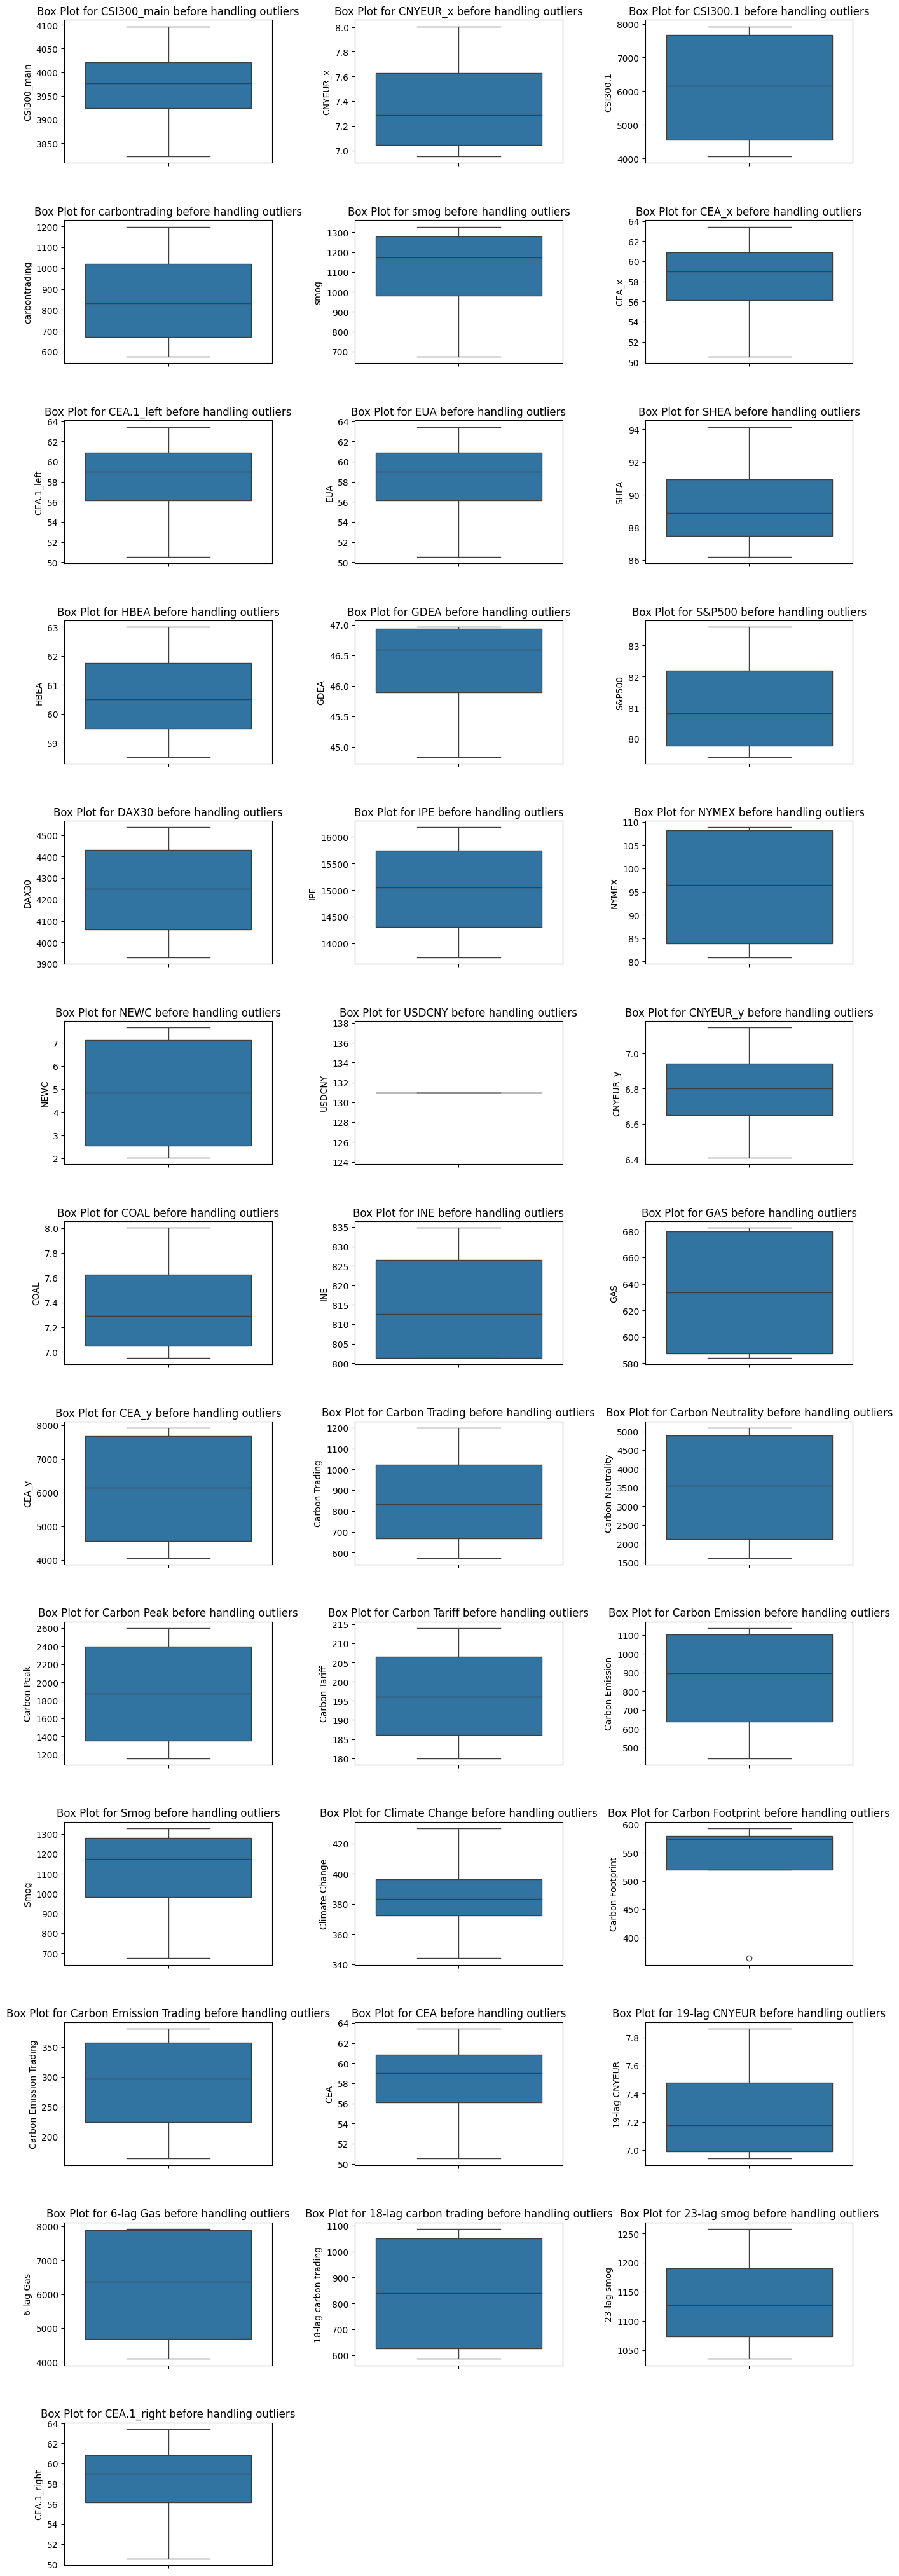

In [39]:
num_cols = 3
num_rows = math.ceil(len(numerical_col) / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_col):
    sns.boxplot(data=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot for {col} before handling outliers')
for ax in axes[len(numerical_col):]:
    ax.set_visible(False)
plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.show()

In [40]:
df.columns

Index(['CSI300_main', 'CNYEUR_x', 'CSI300.1', 'carbontrading', 'smog', 'CEA_x',
       'CEA.1_left', 'day', 'EUA', 'SHEA', 'HBEA', 'GDEA', 'S&P500', 'DAX30',
       'IPE', 'NYMEX', 'NEWC', 'USDCNY', 'CNYEUR_y', 'COAL', 'INE', 'GAS',
       'CEA_y', 'Carbon Trading', 'Carbon Neutrality', 'Carbon Peak',
       'Carbon Tariff', 'Carbon Emission', 'Smog', 'Climate Change',
       'Carbon Footprint', 'Carbon Emission Trading', 'CEA', '19-lag CNYEUR',
       '6-lag Gas', '18-lag carbon trading', '23-lag smog', 'CEA.1_right'],
      dtype='object')

In [41]:
col_with_outliers=['carbontrading','somg','CEA_x','CEA.1_left','EUA','HBEA','GDEA','IPE','COAL','CEA_y','Carbon Trading','Carbon Neutrality','Carbon Peak','Carbon Tariff','Carbon Emission']